In [1]:
from roboflow import Roboflow
import os
import shutil
import random
import yaml

# 1. Download Dataset
rf = Roboflow(api_key="9X8ClVkM9agUJAH3hcAN")
project = rf.workspace("hard-drive").project("hdd_global_scout")
version = project.version(3)
dataset = version.download("yolov8")

DATA_PATH = dataset.location
OUTPUT_DIR = "dataset_rfdetr_box_1080"

# 2. Create directory structure
for split in ['train', 'valid', 'test']:
    os.makedirs(os.path.join(OUTPUT_DIR, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, split, 'labels'), exist_ok=True)

images_dir = os.path.join(DATA_PATH, "train", "images")
labels_dir = os.path.join(DATA_PATH, "train", "labels")

# 3. Shuffle and split (80% Train, 10% Val, 10% Test)
images = [f for f in os.listdir(images_dir) if f.endswith('.jpg')]
random.seed(42)
random.shuffle(images)

train_idx, val_idx = int(len(images) * 0.8), int(len(images) * 0.9)
splits = {'train': images[:train_idx], 'valid': images[train_idx:val_idx], 'test': images[val_idx:]}

# 4. Convert Polygons to Bounding Boxes
for split_name, img_list in splits.items():
    for img_name in img_list:
        # Copy Image
        shutil.copy(os.path.join(images_dir, img_name), os.path.join(OUTPUT_DIR, split_name, 'images', img_name))
        
        # Clean and Copy Label
        label_name = img_name.replace('.jpg', '.txt')
        label_src = os.path.join(labels_dir, label_name)
        label_dest = os.path.join(OUTPUT_DIR, split_name, 'labels', label_name)
        
        if os.path.exists(label_src):
            with open(label_src, 'r') as f_in:
                lines = f_in.readlines()
            
            cleaned_lines = []
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = parts[0]
                    # Extract all polygon coordinates
                    coords = [float(p) for p in parts[1:]]
                    
                    # Separate X and Y coordinates
                    x_coords = coords[0::2]
                    y_coords = coords[1::2]
                    
                    # Calculate the bounding box that wraps the polygon
                    min_x, max_x = min(x_coords), max(x_coords)
                    min_y, max_y = min(y_coords), max(y_coords)
                    
                    cx = (min_x + max_x) / 2.0
                    cy = (min_y + max_y) / 2.0
                    w = max_x - min_x
                    h = max_y - min_y
                    
                    # Format exactly as YOLO Bounding Box: class cx cy w h
                    cleaned_lines.append(f"{class_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
            
            with open(label_dest, 'w') as f_out:
                f_out.write("\n".join(cleaned_lines) + "\n")

# 5. Fix data.yaml paths for RF-DETR
with open(os.path.join(DATA_PATH, 'data.yaml'), 'r') as f:
    data_yaml = yaml.safe_load(f)

data_yaml['train'] = 'train/images'
data_yaml['val'] = 'valid/images'
data_yaml['test'] = 'test/images'

with open(os.path.join(OUTPUT_DIR, 'data.yaml'), 'w') as f:
    yaml.dump(data_yaml, f)

print(f"✅ Dataset split! Polygons successfully converted to Bounding Boxes in {OUTPUT_DIR}/")

loading Roboflow workspace...
loading Roboflow project...
✅ Dataset split! Polygons successfully converted to Bounding Boxes in dataset_rfdetr_box_1080/


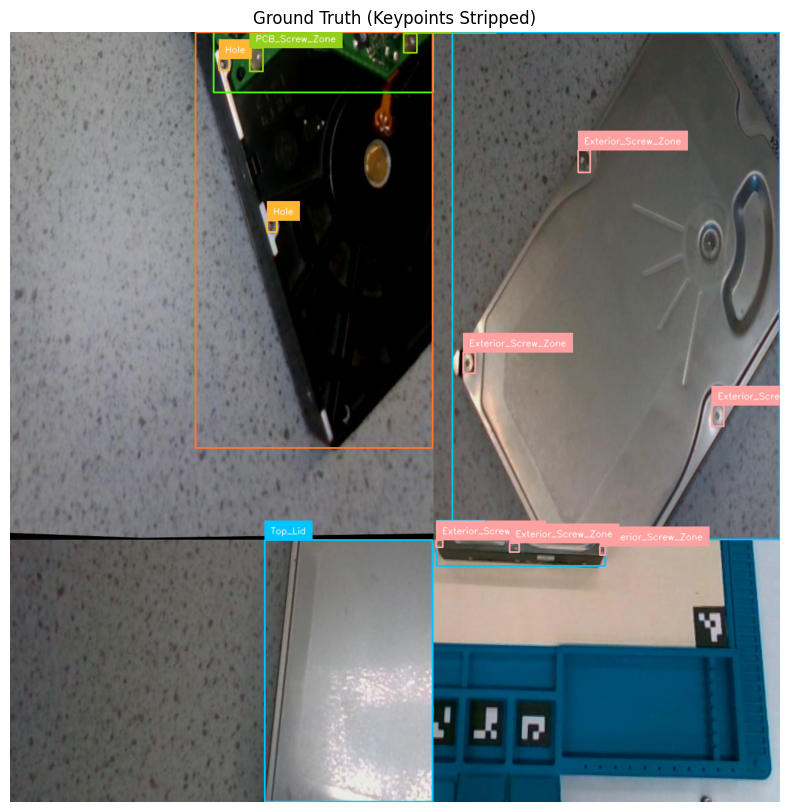

In [2]:
import supervision as sv
import cv2
import matplotlib.pyplot as plt

# Load dataset into Supervision to verify the bounding boxes are clean
dataset = sv.DetectionDataset.from_yolo(
    images_directory_path=os.path.join(OUTPUT_DIR, 'train', 'images'),
    annotations_directory_path=os.path.join(OUTPUT_DIR, 'train', 'labels'),
    data_yaml_path=os.path.join(OUTPUT_DIR, 'data.yaml')
)

image_name, image, annotations = dataset[0]

# Setup Box Annotator
box_annotator = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator()

with open(os.path.join(OUTPUT_DIR, 'data.yaml'), 'r') as f:
    classes = yaml.safe_load(f)['names']

labels = [classes[class_id] for class_id in annotations.class_id]

# Apply Annotations
annotated_image = box_annotator.annotate(scene=image.copy(), detections=annotations)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=annotations, labels=labels)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Ground Truth (Keypoints Stripped)")
plt.show()

In [6]:
from rfdetr import RFDETRLarge

# Initialize the pure detection variant
model = RFDETRLarge()
RUN_DIR = "runs/train/rfdetr_box_1088" # Updated folder name

# Train the model
model.train(
    dataset_dir=OUTPUT_DIR,
    output_dir=RUN_DIR,
    epochs=100,
    batch_size=2,          # Safe for 8GB VRAM
    grad_accum_steps=8,    # Simulates a batch size of 16 (2 * 8) for stability
    resolution=1088        # The AI-safe equivalent of 1080
)

[2026-03-12 00:41:51] [INFO] rf-detr - File rf-detr-large-2026.pth already exists with correct MD5 hash.


[2026-03-12 00:41:51] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-12 00:41:51] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-12 00:41:52] [INFO] rf-detr - Loading pretrain weights


[2026-03-12 00:41:52] [WARNING] rf-detr - Reinitializing your detection head with 15 classes.
[2026-03-12 00:41:52] [WARNING] rf-detr - Unable to initialize TensorBoard. Logging is turned off for this session. Run 'pip install tensorboard' to enable logging.


[2026-03-12 00:41:52] [INFO] rf-detr - Not using distributed mode
[2026-03-12 00:41:52] [INFO] rf-detr - git:
  sha: 92f790b04f92aba2707bbddb43594e9c53694f63, status: has uncommitted changes, branch: devel_agent_v4

[2026-03-12 00:41:52] [INFO] rf-detr - Namespace(num_classes=15, grad_accum_steps=8, print_freq=10, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=2, weight_decay=0.0001, epochs=100, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-large-2026.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[3, 6, 9, 12], freeze_encoder=False, layer_norm=True, rms_norm=False, backbone_lora=False, force_no_pretrain=False

...

[2026-03-12 06:35:31] [INFO] rf-detr - Epoch: [96/100]  [  0/111]  eta: 0:05:25  lr: 0.000100  class_error: 4.81  loss: 3.5971 (3.5971)  loss_ce: 0.2887 (0.2887)  loss_bbox: 0.0449 (0.0449)  loss_giou: 0.2902 (0.2902)  loss_ce_0: 0.4238 (0.4238)  loss_bbox_0: 0.0910 (0.0910)  loss_giou_0: 0.3210 (0.3210)  loss_ce_1: 0.2942 (0.2942)  loss_bbox_1: 0.0489 (0.0489)  loss_giou_1: 0.2943 (0.2943)  loss_ce_2: 0.2911 (0.2911)  loss_bbox_2: 0.0466 (0.0466)  loss_giou_2: 0.2860 (0.2860)  loss_ce_enc: 0.4346 (0.4346)  loss_bbox_enc: 0.0955 (0.0955)  loss_giou_enc: 0.3462 (0.3462)  loss_ce_unscaled: 0.2887 (0.2887)  class_error_unscaled: 4.8077 (4.8077)  loss_bbox_unscaled: 0.0090 (0.0090)  loss_giou_unscaled: 0.1451 (0.1451)  cardinality_error_unscaled: 3880.0000 (3880.0000)  loss_ce_0_unscaled: 0.4238 (0.4238)  loss_bbox_0_unscaled: 0.0182 (0.0182)  loss_giou_0_unscaled: 0.1605 (0.1605)  cardinality_error_0_unscaled: 3880.0000 (3880.0000)  loss_ce_1_unscaled: 0.2942 (0.2942)  loss_bbox_1_unscale

[2026-03-12 06:39:16] [INFO] rf-detr - Epoch: [97/100]  [  0/111]  eta: 0:05:45  lr: 0.000100  class_error: 0.00  loss: 3.8291 (3.8291)  loss_ce: 0.3683 (0.3683)  loss_bbox: 0.0874 (0.0874)  loss_giou: 0.2642 (0.2642)  loss_ce_0: 0.4180 (0.4180)  loss_bbox_0: 0.0659 (0.0659)  loss_giou_0: 0.2678 (0.2678)  loss_ce_1: 0.3718 (0.3718)  loss_bbox_1: 0.0855 (0.0855)  loss_giou_1: 0.2659 (0.2659)  loss_ce_2: 0.3694 (0.3694)  loss_bbox_2: 0.0867 (0.0867)  loss_giou_2: 0.2649 (0.2649)  loss_ce_enc: 0.4579 (0.4579)  loss_bbox_enc: 0.1119 (0.1119)  loss_giou_enc: 0.3436 (0.3436)  loss_ce_unscaled: 0.3683 (0.3683)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_unscaled: 0.0175 (0.0175)  loss_giou_unscaled: 0.1321 (0.1321)  cardinality_error_unscaled: 3883.5000 (3883.5000)  loss_ce_0_unscaled: 0.4180 (0.4180)  loss_bbox_0_unscaled: 0.0132 (0.0132)  loss_giou_0_unscaled: 0.1339 (0.1339)  cardinality_error_0_unscaled: 3883.5000 (3883.5000)  loss_ce_1_unscaled: 0.3718 (0.3718)  loss_bbox_1_unscale

[2026-03-12 06:43:07] [INFO] rf-detr - Epoch: [98/100]  [  0/111]  eta: 0:05:54  lr: 0.000100  class_error: 0.23  loss: 3.2759 (3.2759)  loss_ce: 0.3579 (0.3579)  loss_bbox: 0.0306 (0.0306)  loss_giou: 0.2008 (0.2008)  loss_ce_0: 0.4236 (0.4236)  loss_bbox_0: 0.0478 (0.0478)  loss_giou_0: 0.2084 (0.2084)  loss_ce_1: 0.3772 (0.3772)  loss_bbox_1: 0.0433 (0.0433)  loss_giou_1: 0.1999 (0.1999)  loss_ce_2: 0.3638 (0.3638)  loss_bbox_2: 0.0325 (0.0325)  loss_giou_2: 0.1991 (0.1991)  loss_ce_enc: 0.4526 (0.4526)  loss_bbox_enc: 0.0818 (0.0818)  loss_giou_enc: 0.2564 (0.2564)  loss_ce_unscaled: 0.3579 (0.3579)  class_error_unscaled: 0.2331 (0.2331)  loss_bbox_unscaled: 0.0061 (0.0061)  loss_giou_unscaled: 0.1004 (0.1004)  cardinality_error_unscaled: 3883.5000 (3883.5000)  loss_ce_0_unscaled: 0.4236 (0.4236)  loss_bbox_0_unscaled: 0.0096 (0.0096)  loss_giou_0_unscaled: 0.1042 (0.1042)  cardinality_error_0_unscaled: 3883.5000 (3883.5000)  loss_ce_1_unscaled: 0.3772 (0.3772)  loss_bbox_1_unscale

[2026-03-12 06:46:46] [INFO] rf-detr - Epoch: [99/100]  [  0/111]  eta: 0:04:45  lr: 0.000100  class_error: 0.00  loss: 2.9879 (2.9879)  loss_ce: 0.3095 (0.3095)  loss_bbox: 0.0336 (0.0336)  loss_giou: 0.2285 (0.2285)  loss_ce_0: 0.3288 (0.3288)  loss_bbox_0: 0.0311 (0.0311)  loss_giou_0: 0.2077 (0.2077)  loss_ce_1: 0.3091 (0.3091)  loss_bbox_1: 0.0323 (0.0323)  loss_giou_1: 0.2230 (0.2230)  loss_ce_2: 0.3098 (0.3098)  loss_bbox_2: 0.0337 (0.0337)  loss_giou_2: 0.2261 (0.2261)  loss_ce_enc: 0.3822 (0.3822)  loss_bbox_enc: 0.0644 (0.0644)  loss_giou_enc: 0.2681 (0.2681)  loss_ce_unscaled: 0.3095 (0.3095)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_unscaled: 0.0067 (0.0067)  loss_giou_unscaled: 0.1143 (0.1143)  cardinality_error_unscaled: 3888.0000 (3888.0000)  loss_ce_0_unscaled: 0.3288 (0.3288)  loss_bbox_0_unscaled: 0.0062 (0.0062)  loss_giou_0_unscaled: 0.1039 (0.1039)  cardinality_error_0_unscaled: 3888.0000 (3888.0000)  loss_ce_1_unscaled: 0.3091 (0.3091)  loss_bbox_1_unscale

[2026-03-12 06:50:29] [INFO] rf-detr - Epoch: [100/100]  [  0/111]  eta: 0:05:27  lr: 0.000100  class_error: 0.00  loss: 2.8165 (2.8165)  loss_ce: 0.2765 (0.2765)  loss_bbox: 0.0162 (0.0162)  loss_giou: 0.2031 (0.2031)  loss_ce_0: 0.3181 (0.3181)  loss_bbox_0: 0.0254 (0.0254)  loss_giou_0: 0.2238 (0.2238)  loss_ce_1: 0.2869 (0.2869)  loss_bbox_1: 0.0193 (0.0193)  loss_giou_1: 0.2123 (0.2123)  loss_ce_2: 0.2784 (0.2784)  loss_bbox_2: 0.0166 (0.0166)  loss_giou_2: 0.2070 (0.2070)  loss_ce_enc: 0.3920 (0.3920)  loss_bbox_enc: 0.0507 (0.0507)  loss_giou_enc: 0.2903 (0.2903)  loss_ce_unscaled: 0.2765 (0.2765)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_unscaled: 0.0032 (0.0032)  loss_giou_unscaled: 0.1016 (0.1016)  cardinality_error_unscaled: 3877.5000 (3877.5000)  loss_ce_0_unscaled: 0.3181 (0.3181)  loss_bbox_0_unscaled: 0.0051 (0.0051)  loss_giou_0_unscaled: 0.1119 (0.1119)  cardinality_error_0_unscaled: 3877.5000 (3877.5000)  loss_ce_1_unscaled: 0.2869 (0.2869)  loss_bbox_1_unscal

In [7]:
import json
import pandas as pd
import os

RUN_DIR = "runs/train/rfdetr_box_1088"
log_file = os.path.join(RUN_DIR, 'log.txt')

if os.path.exists(log_file):
    records = []
    with open(log_file, 'r') as f:
        for line in f:
            try:
                # RF-DETR writes each epoch's stats as a JSON line
                records.append(json.loads(line.strip()))
            except json.JSONDecodeError:
                continue # Skip non-JSON lines

    df = pd.DataFrame(records)
    
    # In standard DETR architectures, the mAP metrics are stored in a list 
    # under the key 'test_coco_eval_bbox'. The first item is mAP 50-95.
    if 'test_coco_eval_bbox' in df.columns:
        # Extract the first element (mAP 0.5:0.95) from the evaluation array
        best_box_map = df['test_coco_eval_bbox'].dropna().apply(lambda x: x[0]).max()
        print(f"🏆 Best Bounding Box mAP (50-95): {best_box_map:.4f}")
    else:
        # Fallback just in case the keys are named differently
        print("Metrics loaded successfully! Available columns:")
        print(df.columns.tolist())
else:
    print("❌ log.txt file not found. Ensure training completed.")

🏆 Best Bounding Box mAP (50-95): 0.8170


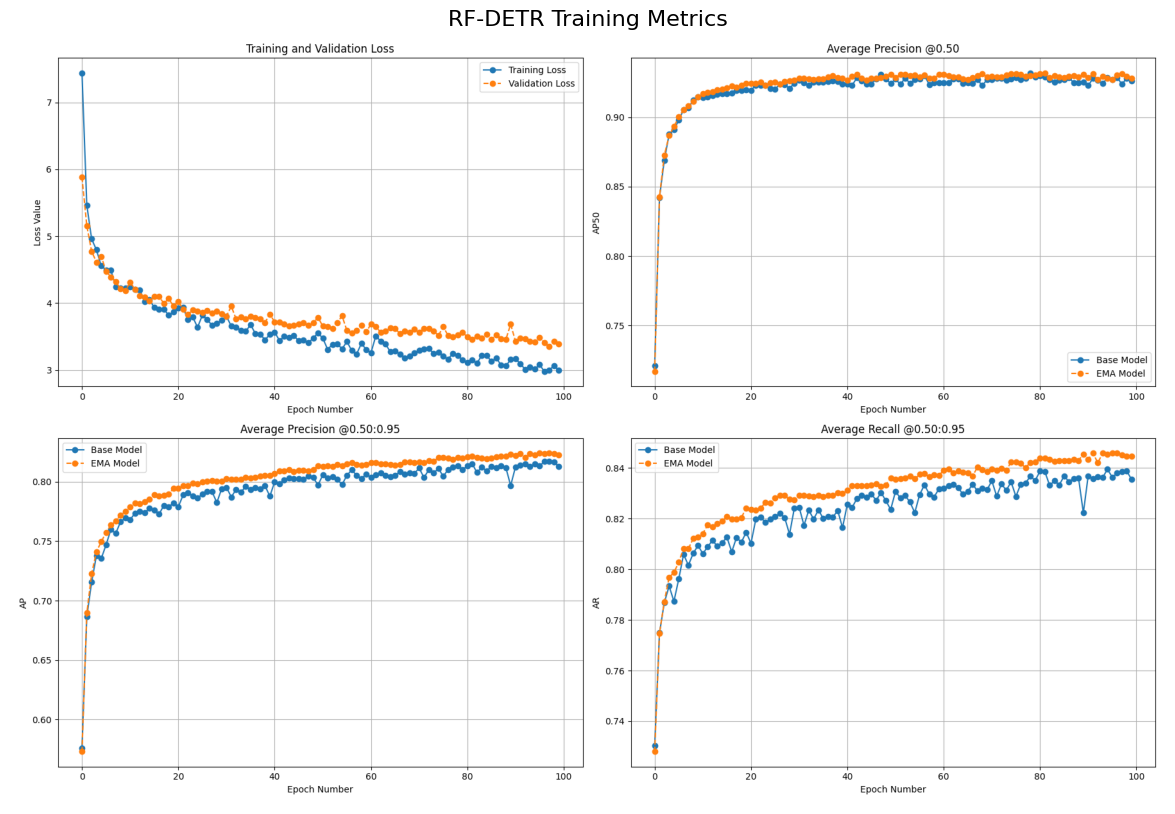

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

RUN_DIR = "runs/train/rfdetr_box_1088"
plot_path = os.path.join(RUN_DIR, 'metrics_plot.png')

if os.path.exists(plot_path):
    plt.figure(figsize=(15, 10))
    img = mpimg.imread(plot_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title("RF-DETR Training Metrics", fontsize=16)
    plt.show()
else:
    print(f"⚠️ {plot_path} not found.")

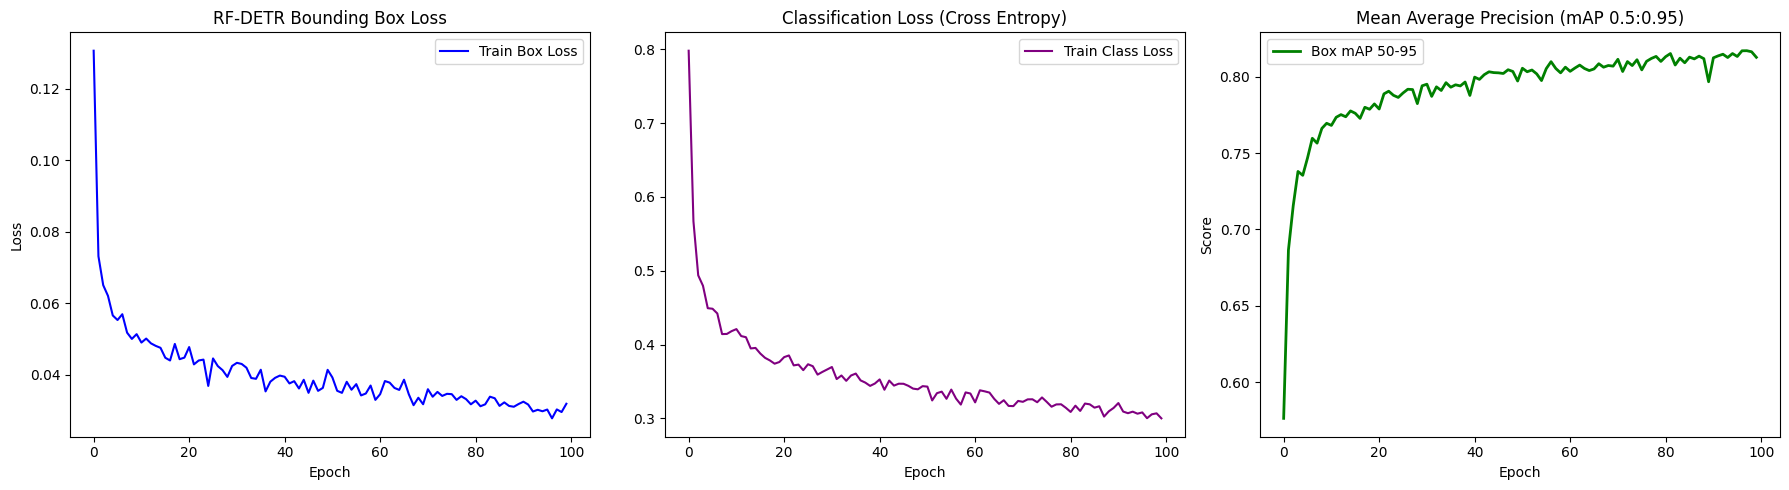

In [9]:
import matplotlib.pyplot as plt

# Ensure the dataframe from the previous log.txt parsing cell exists
if 'df' in locals() and not df.empty:
    plt.figure(figsize=(18, 5))

    # --- 1. Bounding Box Loss ---
    plt.subplot(1, 3, 1)
    if 'train_loss_bbox' in df.columns:
        # DETR logs usually prefix with 'train_'
        plt.plot(df['epoch'], df['train_loss_bbox'], label='Train Box Loss', color='blue')
    plt.title('RF-DETR Bounding Box Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # --- 2. Classification Loss ---
    plt.subplot(1, 3, 2)
    if 'train_loss_ce' in df.columns:
        plt.plot(df['epoch'], df['train_loss_ce'], label='Train Class Loss', color='purple')
    plt.title('Classification Loss (Cross Entropy)')
    plt.xlabel('Epoch')
    plt.legend()

    # --- 3. Bounding Box mAP ---
    plt.subplot(1, 3, 3)
    if 'test_coco_eval_bbox' in df.columns:
        # mAP is stored as an array where index 0 is mAP 50-95.
        # We drop NaNs because evaluation might not happen every single epoch.
        eval_data = df.dropna(subset=['test_coco_eval_bbox'])
        map_scores = eval_data['test_coco_eval_bbox'].apply(lambda x: x[0])
        plt.plot(eval_data['epoch'], map_scores, label='Box mAP 50-95', color='green', linewidth=2)
        
    plt.title('Mean Average Precision (mAP 0.5:0.95)')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("❌ Dataframe 'df' not found. Make sure you ran the Cell 5 code to parse log.txt!")

[2026-03-12 09:13:56] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-12 09:13:56] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-12 09:13:56] [INFO] rf-detr - Loading pretrain weights


[2026-03-12 09:13:57] [WARNING] rf-detr - Reinitializing detection head with 14 classes based on pretrained weights, configured for 90.
[2026-03-12 09:13:57] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


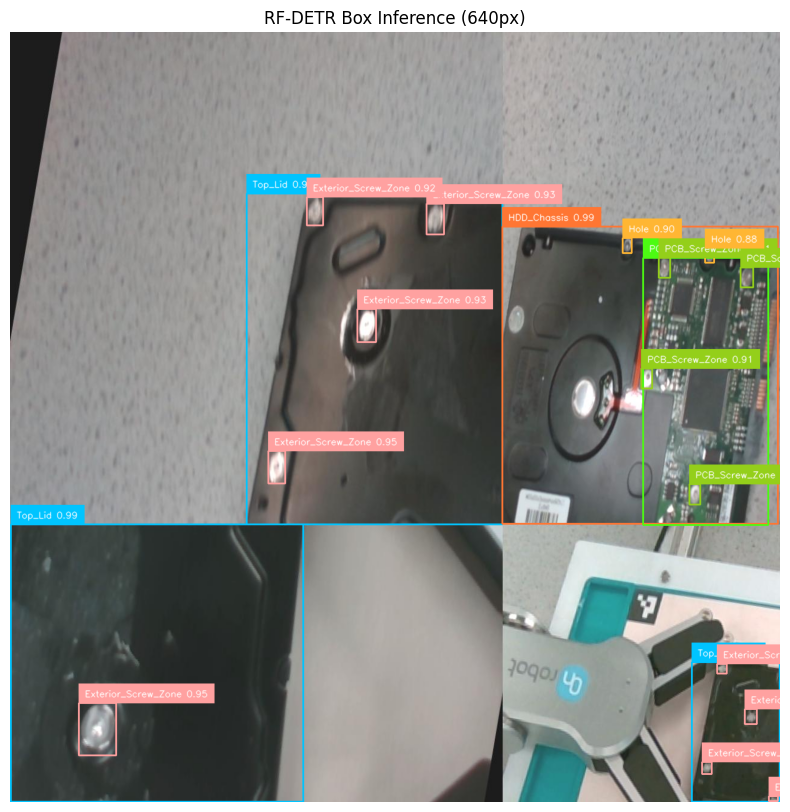

In [12]:
from PIL import Image
import numpy as np

# Load the BEST weights (Exponential Moving Average weights)
weights_path = os.path.join(RUN_DIR, "checkpoint_best_ema.pth")

# Re-initialize model with the trained weights
model = RFDETRLarge(pretrain_weights=weights_path, resolution=1088)

# Grab a random test image
test_images_dir = os.path.join(OUTPUT_DIR, 'test', 'images')
test_img_path = os.path.join(test_images_dir, os.listdir(test_images_dir)[0])
pil_image = Image.open(test_img_path)

# Run Inference
detections = model.predict(pil_image, threshold=0.4)

# Convert PIL image to CV2 format for Supervision drawing
cv_image = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)

# Setup Annotators
box_annotator = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_scale=0.5, text_padding=10)

# Generate Labels with Confidence
labels = [
    f"{classes[class_id]} {confidence:.2f}"
    for class_id, confidence in zip(detections.class_id, detections.confidence)
]

# Apply Annotations
annotated_image = box_annotator.annotate(scene=cv_image.copy(), detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections, labels=labels)

# Display
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("RF-DETR Box Inference (640px)")
plt.show()